In [12]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
import pandas as pd
from netCDF4 import Dataset
from scipy import stats
import scipy.stats as stats
import matplotlib.pyplot as plt

# Period used for ERA5

In [13]:
iyear = 1960
fyear = 2025

# Subregions used

In [14]:
domains = ['HMA','HK','SL','TP','CH','SEH']

# Atmospheric moisture variables

In [15]:
variables = ['tcwv', 'vimd']

# Atmospheric moisture variables data loading

In [16]:
var_dict = {} # dictionnary to store atmospheric moisture variables

# path to the tcwv & vimd data
files = {'tcwv': 'tcwv_monthly_era5_1940-2025_NH_025x025.nc',
         'vimd': 'vimd_monthly_era5_1940-2025_NH_025x025.nc'}
path = '/bettik/PROJECTS/pr-regional-climate/bricej/era5/monthly/'


for var in variables:
    var_dict[var] = {}
    var_data = xr.open_dataset(path + files[var])[var]

    # rename dimension to have the same everywhere
    var_data = var_data.rename({'valid_time': 'time'})
    var_data = var_data.rename({'longitude': 'lon'})
    var_data = var_data.rename({'latitude': 'lat'})

    # pour alléger le dossier 
    var_data = var_data.drop_vars(['number','expver'], errors='ignore')  # les variables inutiles
    var_data.attrs = {}  # les atributs pas utiles pour les calculs
    
    var_data = var_data.sel(time=slice(str(iyear),str(fyear))) # only the period wanted of ERA5
    
    for domain in domains:
            var_dict[var][domain] = field_dom(var_data,domain) # focus on the domain

# Atmospheric moisture variables monthly mean (temporally and spatially)

In [17]:
var_mean_dict = {} # dictionnary to store the monthly mean of tcwv & vimd

for var in variables:
    var_mean_dict[var]={}
    for domain in domains:
        var_mean_dict[var][domain] = var_dict[var][domain].groupby('time.month').mean('time', skipna=True) # temporal mean
        var_mean_dict[var][domain] = var_mean_dict[var][domain].mean(dim=['lat','lon'], skipna=True) # spatial mean

# Precipitation data loading

In [18]:
models = ['CHIRPS','ERA5'] # precipitation datasets used here

tp_datasets = {} # dictionnary to store precipitation data

# path to the precipitation datasets
files = {'CHIRPS': 'tp_HMA_1981-2025_CHIRPS.nc',
        'ERA5': 'tp_HMA_1940-2025_ERA5.nc'}
path = '/bettik/PROJECTS/pr-regional-climate/bricej/tp_datasets/'


for model in models:
    tp_datasets[model] = {}
    tp_model = xr.open_dataset(path + files[model])['tp']
    if model=='ERA5':
        tp_model=tp_model.sel(time=slice(str(iyear),str(fyear))) # for ERA5 the same period of 1960-2025
    else:
            tp_model=tp_model.sel(time=slice(str(1981),str(2024))) # for CHIRPS the period available : 1981-2024
    for domain in domains:
        tp_datasets[model][domain] = field_dom(tp_model,domain)

# Precipitation monthly mean (temporally and spatially)

In [19]:
tp_mean_dict = {} # dictionnary to store the monthly mean of precipitation

for model in models:
    tp_mean_dict[model]={}
    for domain in domains:
        tp_mean_dict[model][domain] = tp_datasets[model][domain].groupby('time.month').mean('time', skipna=True) # temporal mean
        tp_mean_dict[model][domain] = tp_mean_dict[model][domain].mean(dim=['lat','lon'], skipna=True) # spatial mean

# Final plot : annual cycle of tcwv (blue) & vimd (green) & precipitation (ERA5 in red, and CHIRPS in orange)

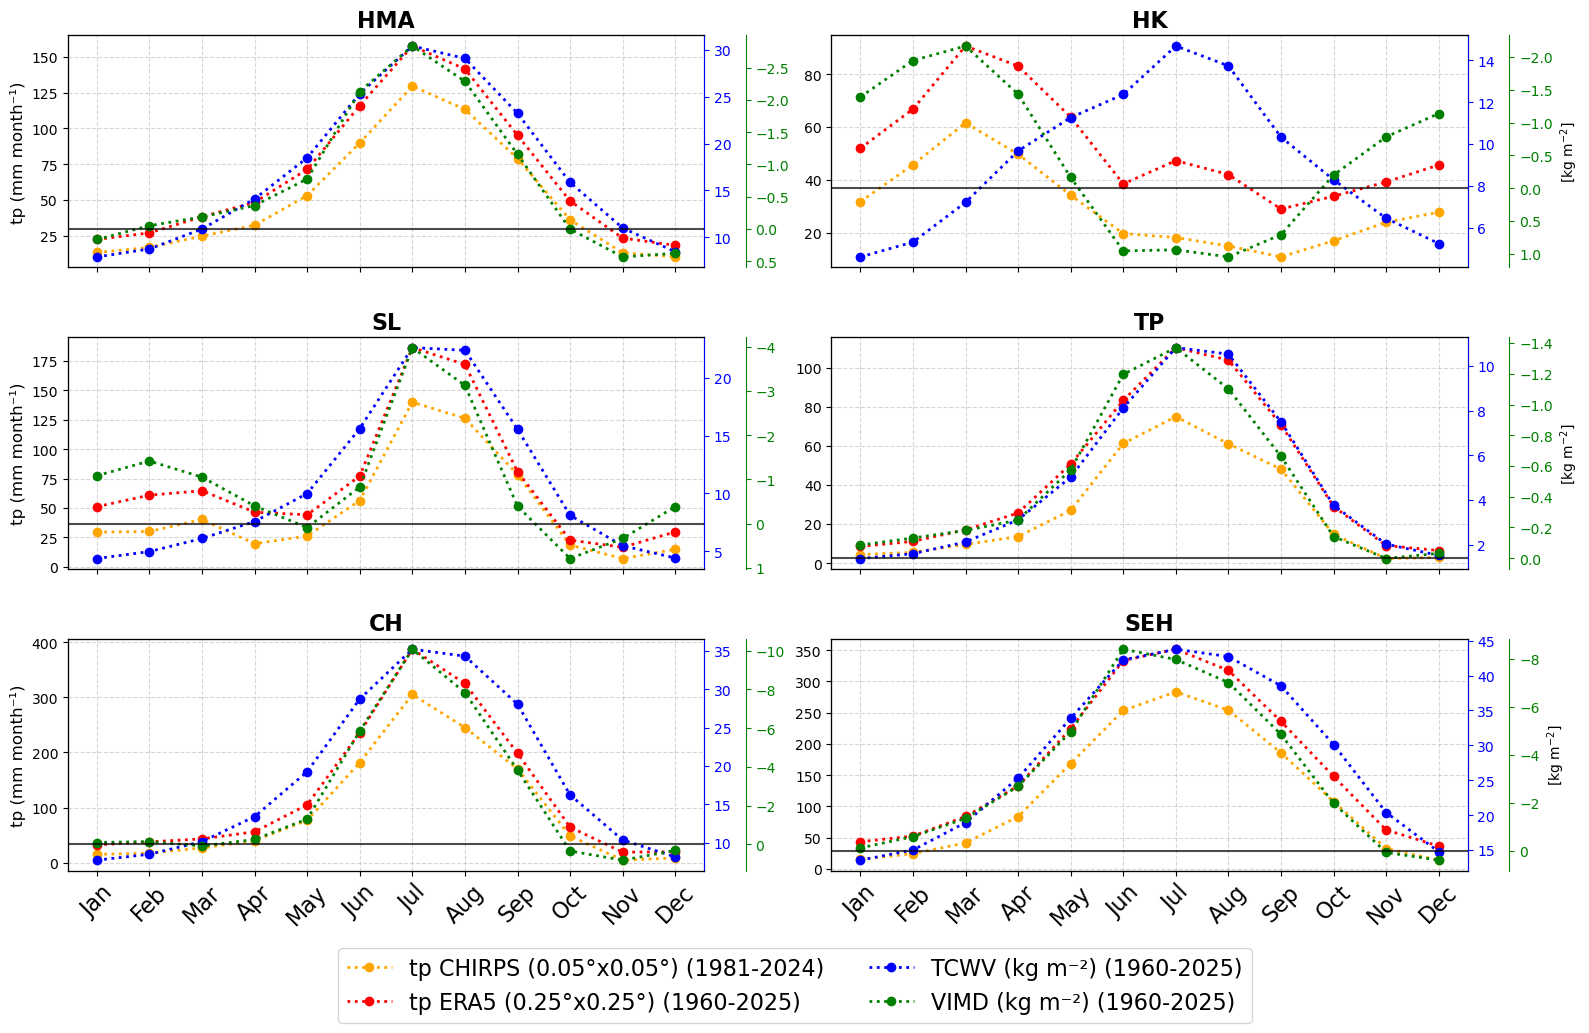

In [20]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'] # month of the year

# spatial resolution of the precipitation datasets
resolutions = {'CHIRPS': '0.05°x0.05°',
               'ERA5': '0.25°x0.25°'}
# temporal coverage of the precipitation datasets
period = {'CHIRPS': '1981-2024',
               'ERA5': '1960-2025'}
# color for the plot of the precipitation datasets
colors = {'CHIRPS': 'orange',
          'ERA5': 'red'}

# figure
fig, axes = plt.subplots(3, 2, figsize=(16,10))
axes = axes.flatten()

# to store the legend
handles_all = []
labels_all = []

for i, dom in enumerate(domains):
    ax = axes[i]
    
    ax2 = ax.twinx()  # axe droit 1 : tcwv
    # mettre l'axe droit en bleu
    ax2.tick_params(axis='y', colors='blue') # ticks
    ax2.yaxis.label.set_color('blue') # labels
    ax2.spines['right'].set_color('blue') # ax

    ax3 = ax.twinx()  # axe droit 2 : vimd
    ax3.invert_yaxis() # inverser l'axe
    ax3.spines['right'].set_position(('outward', 30))  # décale de 60 points vers la droite pour plus de clareté entre tcwv et vimd axes
    # mettre l'axe droit en vert
    ax3.tick_params(axis='y', colors='green')
    ax3.yaxis.label.set_color('green')
    ax3.spines['right'].set_color('green')

    # precipitation (axe gauche)
    for model in models:
        da = tp_mean_dict[model][dom]
        l, = ax.plot(
            da['month'], da.values,
            marker='o', linestyle=':',
            color=colors[model],
            label=f'tp {model} ({resolutions[model]}) ({period[model]})',
            linewidth=2
        )

        # stocker une seule fois la légende des précipitations
        if i == 0:
            handles_all.append(l)
            labels_all.append(l.get_label())

    # TCWV (axe droit 1, blue)
    da_tcwv = var_mean_dict['tcwv'][dom]
    l_tcwv, = ax2.plot(
        da_tcwv['month'], da_tcwv.values,
        marker='o', linestyle=':',
        color='blue',
        label=f'TCWV (kg m⁻²) ({period[model]})',
        linewidth=2
    )

    # VIMD (axe droit 2, green)
    da_vimd = var_mean_dict['vimd'][dom]
    l_tcwv2, = ax3.plot(
        da_vimd['month'], da_vimd.values,
        marker='o', linestyle=':',
        color='green',
        label=f'VIMD (kg m⁻²) ({period[model]})',
        linewidth=2
    )

    # ligne horizontale pour la valeur référence 0 de VIMD
    ax3.axhline(y=0,color='black',linestyle='-',linewidth=1.5,alpha=0.7)

    # stocker une seule fois la légende de tcwv & vimd
    if i == 0:
        handles_all.append(l_tcwv)
        labels_all.append(l_tcwv.get_label())
        
        handles_all.append(l_tcwv2)
        labels_all.append(l_tcwv2.get_label())

    # label des domaines pour les subplots
    ax.set_title(dom, fontsize=16, weight="bold")
    ax.set_xticks(range(1,13))

    # month labels only for the last line of the plot
    if i in [4, 5]:
        ax.set_xticklabels(months, rotation=45, fontsize=16)
    else:
        ax.tick_params(labelbottom=False)

    # precipitation ax label
    if i in [0, 2, 4]:
        ax.set_ylabel('tp (mm month⁻¹)', fontsize=12)
    # tcwv & vimd ax label (unity)
    if i in [1, 3, 5]:
        ax3.set_ylabel(r'[kg m$^{-2}$]', color='black')

    ax.grid(True, linestyle='--', alpha=0.5)

# legend
fig.legend(handles_all,labels_all,loc='lower center',bbox_to_anchor=(0.5, -0.04),ncol=2,fontsize=16,frameon=True)

# adjust the parameters to have a beautiful plot
plt.tight_layout(rect=[0,0.05,1,1])
plt.subplots_adjust(hspace=0.3, wspace=0.2)

plt.show()

Figure 5. Annual cycle of precipitation and associated atmospheric moisture variables : precipitation is on the left y-axis (tp, mm.month-1). Total Column Water Vapor (TCWV, kg·m⁻²) and Vertical Integral of Moisture Divergence (VIMD, kg·m⁻²) are on the right y-axis. The horizontal black line indicates the zero reference of VIMD. High Mountain Asia (HMA). Subfigures (b-f) represent subregions (see Fig. 2).